In [ ]:
!pip install -q kagglehub nltk wordcloud

In [ ]:
import kagglehub
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from wordcloud import WordCloud

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [ ]:
import kagglehub

path = kagglehub.dataset_download(
    "lakshmi25npathi/imdb-dataset-of-50k-movie-reviews"
)

print("Path to dataset files:", path)

100%|██████████| 25.7M/25.7M [00:00<00:00, 75.9MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/versions/1


In [ ]:
import os

print(os.listdir(path))

['IMDB Dataset.csv']


In [ ]:
file_path = os.path.join(path, "IMDB Dataset.csv")

df = pd.read_csv(file_path)

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [ ]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nMissing values:")
print(df.isnull().sum())

print("\nSentiment distribution:")
print(df['sentiment'].value_counts())

Shape: (50000, 2)

Columns:
Index(['review', 'sentiment'], dtype='object')

Missing values:
review       0
sentiment    0
dtype: int64

Sentiment distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


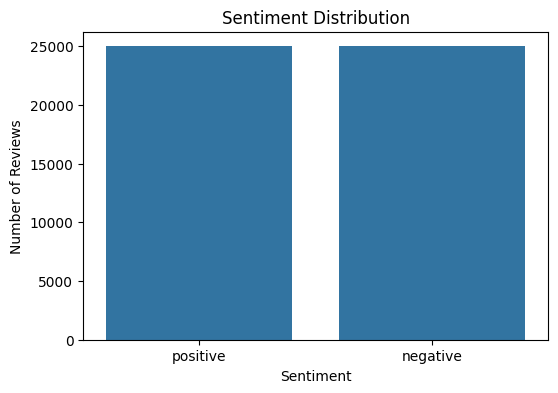

In [ ]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x='sentiment'
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

In [ ]:
stop_words = set(stopwords.words('english'))

lemmatizer = WordNetLemmatizer()

In [ ]:
def clean_text(text):

    # Lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r'<.*?>', ' ', text)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', ' ', text)

    # Keep only letters
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    # Tokenization
    words = text.split()

    # Remove stopwords + lemmatization
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return ' '.join(words)

In [ ]:
df['clean_review'] = df['review'].apply(clean_text)

df[['review', 'clean_review', 'sentiment']].head()

,review,clean_review,sentiment
0,One of the other reviewers has mentioned that ...,one reviewer mentioned watching oz episode hoo...,positive
1,A wonderful little production. <br /><br />The...,wonderful little production filming technique ...,positive
2,I thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...,positive
3,Basically there's a family where a little boy ...,basically family little boy jake think zombie ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter mattei love time money visually stunnin...,positive


In [ ]:
df['label'] = df['sentiment'].map({
    'negative': 0,
    'positive': 1
})

df[['sentiment', 'label']].head()

,sentiment,label
0,positive,1
1,positive,1
2,positive,1
3,negative,0
4,positive,1


In [ ]:
X = df['clean_review']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 40000
Testing samples: 10000


In [ ]:
tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

print("Training matrix shape:", X_train_tfidf.shape)
print("Testing matrix shape:", X_test_tfidf.shape)

Training matrix shape: (40000, 50000)
Testing matrix shape: (10000, 50000)


In [ ]:
logistic_model = LogisticRegression(
    max_iter=1000
)

logistic_model.fit(
    X_train_tfidf,
    y_train
)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred_lr = logistic_model.predict(X_test_tfidf)

accuracy_lr = accuracy_score(
    y_test,
    y_pred_lr
)

print("Logistic Regression Accuracy:", accuracy_lr)

Logistic Regression Accuracy: 0.9024


In [ ]:
print("Logistic Regression Classification Report:\n")

print(
    classification_report(
        y_test,
        y_pred_lr,
        target_names=['Negative', 'Positive']
    )
)

Logistic Regression Classification Report:

              precision    recall  f1-score   support

    Negative       0.91      0.89      0.90      5000
    Positive       0.89      0.92      0.90      5000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



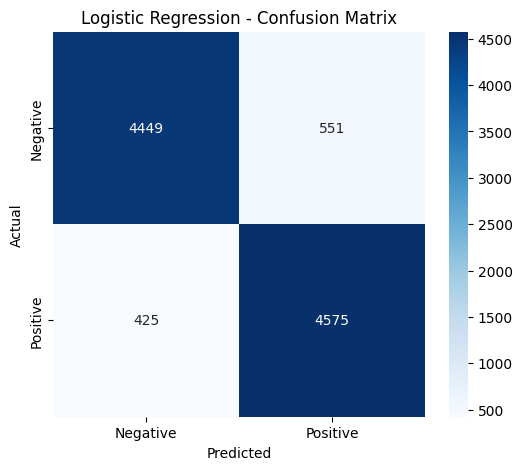

In [ ]:
cm = confusion_matrix(
    y_test,
    y_pred_lr
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive']
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
nb_model = MultinomialNB()

nb_model.fit(
    X_train_tfidf,
    y_train
)

MultinomialNB()

In [ ]:
y_pred_nb = nb_model.predict(X_test_tfidf)

accuracy_nb = accuracy_score(
    y_test,
    y_pred_nb
)

print("Naive Bayes Accuracy:", accuracy_nb)

Naive Bayes Accuracy: 0.8805


In [ ]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Naive Bayes'
    ],
    'Accuracy': [
        accuracy_lr,
        accuracy_nb
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.9024
1,Naive Bayes,0.8805


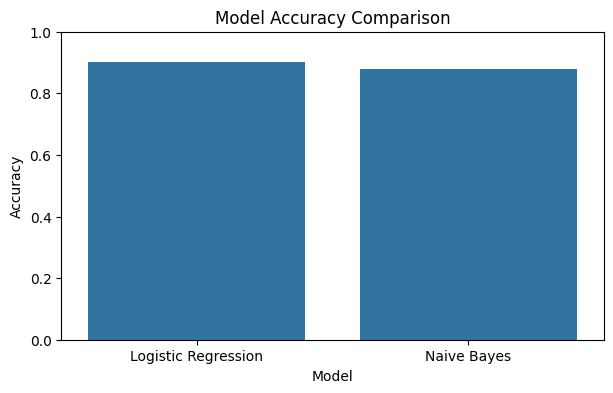

In [ ]:
plt.figure(figsize=(7, 4))

sns.barplot(
    data=results,
    x='Model',
    y='Accuracy'
)

plt.ylim(0, 1)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

plt.show()

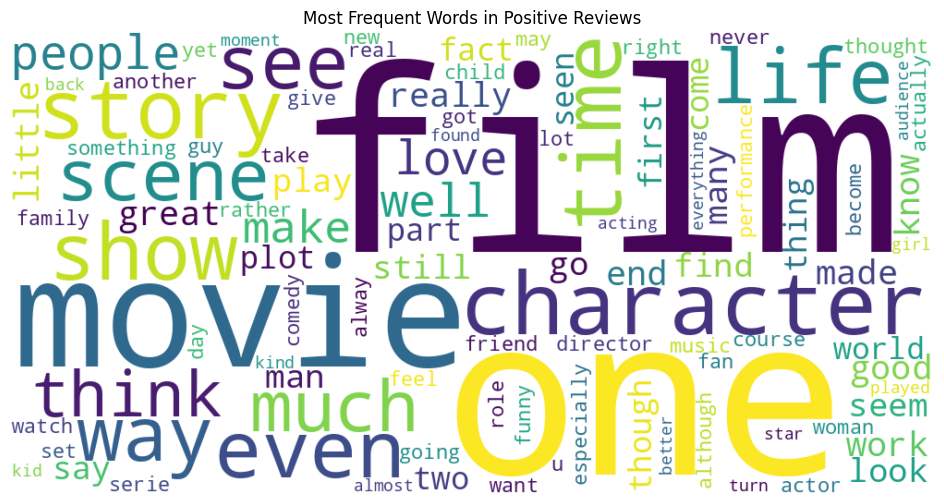

In [ ]:
positive_text = ' '.join(
    df[df['label'] == 1]['clean_review']
)

wordcloud_positive = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    max_words=100
).generate(positive_text)

plt.figure(figsize=(12, 6))

plt.imshow(
    wordcloud_positive,
    interpolation='bilinear'
)

plt.axis('off')
plt.title("Most Frequent Words in Positive Reviews")

plt.show()

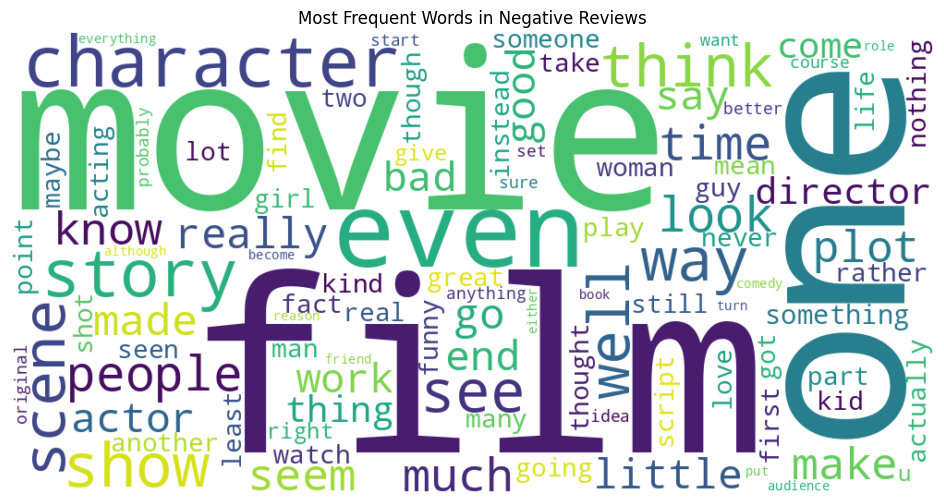

In [ ]:
negative_text = ' '.join(
    df[df['label'] == 0]['clean_review']
)

wordcloud_negative = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    max_words=100
).generate(negative_text)

plt.figure(figsize=(12, 6))

plt.imshow(
    wordcloud_negative,
    interpolation='bilinear'
)

plt.axis('off')
plt.title("Most Frequent Words in Negative Reviews")

plt.show()

In [ ]:
def predict_sentiment(review):

    cleaned = clean_text(review)

    vector = tfidf.transform([cleaned])

    prediction = logistic_model.predict(vector)[0]

    if prediction == 1:
        return "Positive"
    else:
        return "Negative"

In [ ]:
reviews = [
    "This movie was absolutely amazing and I loved every minute of it.",
    "The movie was boring, slow and completely disappointing.",
    "I really enjoyed this film. The acting was excellent.",
    "This was one of the worst movies I have ever watched."
]

for review in reviews:
    print("Review:", review)
    print("Prediction:", predict_sentiment(review))
    print("-" * 70)

Review: This movie was absolutely amazing and I loved every minute of it.
Prediction: Positive
----------------------------------------------------------------------
Review: The movie was boring, slow and completely disappointing.
Prediction: Negative
----------------------------------------------------------------------
Review: I really enjoyed this film. The acting was excellent.
Prediction: Positive
----------------------------------------------------------------------
Review: This was one of the worst movies I have ever watched.
Prediction: Negative
----------------------------------------------------------------------


In [ ]:
feature_names = np.array(
    tfidf.get_feature_names_out()
)

coefficients = logistic_model.coef_[0]

top_positive = np.argsort(coefficients)[-20:][::-1]
top_negative = np.argsort(coefficients)[:20]

print("Top Positive Features:\n")

for index in top_positive:
    print(
        feature_names[index],
        "->",
        round(coefficients[index], 3)
    )

print("\nTop Negative Features:\n")

for index in top_negative:
    print(
        feature_names[index],
        "->",
        round(coefficients[index], 3)
    )

Top Positive Features:

great -> 8.163
excellent -> 7.109
perfect -> 5.696
best -> 5.128
amazing -> 5.075
wonderful -> 5.074
loved -> 4.787
fun -> 4.537
favorite -> 4.464
hilarious -> 4.459
brilliant -> 4.376
one best -> 4.363
well -> 4.193
enjoyed -> 4.192
today -> 4.007
love -> 3.916
superb -> 3.857
must see -> 3.783
still -> 3.747
definitely -> 3.738

Top Negative Features:

worst -> -9.694
bad -> -9.05
awful -> -7.982
waste -> -7.186
boring -> -6.818
poor -> -6.254
terrible -> -5.973
nothing -> -5.827
worse -> -5.101
horrible -> -5.071
dull -> -5.001
poorly -> -4.903
stupid -> -4.793
unfortunately -> -4.548
fails -> -4.544
instead -> -4.493
disappointing -> -4.395
supposed -> -4.331
annoying -> -4.317
minute -> -4.309


In [ ]:
final_results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Naive Bayes'
    ],
    'Accuracy': [
        accuracy_lr,
        accuracy_nb
    ]
})

final_results['Accuracy (%)'] = (
    final_results['Accuracy'] * 100
).round(2)

final_results

,Model,Accuracy,Accuracy (%)
0,Logistic Regression,0.9024,90.24
1,Naive Bayes,0.8805,88.05
